### EuroSAT CNN Classifier with PyTorch

This is my attempt at building a CNN classifier for the EuroSAT dataset as an opportunity to learn more about PyTorch and its vast library of tools.

### About the Dataset
The EuroSAT dataset is a widely used benchmark collection of 27,000 labeled, geo-referenced Sentinel-2 satellite images designed for land use and land cover (LULC) classification

The first step is the required imports. I will be using `Pytorch`, `TorchVision`, and some `Matplotlib`

In [238]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import random_split, Subset


In [236]:
"""old setup"""
# data = datasets.EuroSAT(
#     root="data",
#     transform=v2.Compose([v2.ToImage(), 
#                           v2.ToDtype(torch.float32, scale=True),
#                           v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]),
#     download=True,
# )

"""data augmentation setup"""
class RandomRotate90:
    def __call__(self, img):
        k = int(torch.randint(0, 4, (1,)).item())
        return torch.rot90(img, k, dims=[1, 2])
    
train_transform = v2.Compose([
    v2.ToImage(),
    RandomRotate90(),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

val_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data= datasets.EuroSAT(
    root="data",
    transform=train_transform,
    download=True
)

val_data = datasets.EuroSAT(
    root="data",
    transform=val_transform,
    download=False
)

batch_size = 64
generator = torch.Generator().manual_seed(42)

train_set, test_set, val_set = random_split(
    train_data,
    [0.7, 0.15, 0.15],
    generator=generator
)

test_set = Subset(val_data, test_set.indices)
val_set = Subset(val_data, val_set.indices)

train_dataloader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False
)

val_dataloader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 94.3M/94.3M [00:02<00:00, 45.8MB/s]


Shape of an Image [C, W, H]: torch.Size([3, 64, 64])
Label: AnnualCrop


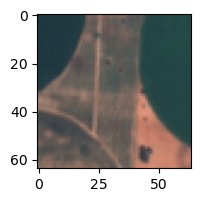

In [ ]:
# img_tensor, label = data[186]
# image = img_tensor.permute(1, 2, 0) * 0.5 + 0.5 # undo normalization
# print(f"Shape of an Image [C, W, H]: {img_tensor.shape}")

# plt.figure(figsize=(2, 2))
# plt.imshow(image)

# print(f"Label: {data.classes[label]}")


In [237]:
"""old setup"""
# train_set, test_set, val_set = random_split(
#     data, [0.7, 0.15, 0.15], generator=generator)

# train_dataloader = DataLoader(train_set, batch_size=batch_size)
# test_dataloader = DataLoader(test_set, batch_size=batch_size)
# val_dataloader = DataLoader(val_set, batch_size=batch_size)

print(f"Train Set: {len(train_set)}")
print(f"Validation Set: {len(val_set)}")
print(f"Test Set: {len(test_set)}\n")
print(f"TOTAL: {len(train_data)}")



Train Set: 18900
Validation Set: 4050
Test Set: 4050

TOTAL: 27000


### Building the Convolutional Neural Network

This defines a CNN with 3 convolution layers (32 -> 64 -> 128 filters) and one fully connected dense layer.

In [242]:
import torch.nn.functional as F

class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)

        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.pool(
            F.relu(self.bn1(self.conv1(x))))

        x = self.pool(
            F.relu(self.bn2(self.conv2(x))))

        x = self.pool(
            F.relu(self.bn3(self.conv3(x))))

        x = self.pool(
                F.relu(self.bn4(self.conv4(x))))

        x = self.flatten(x)
        logits = self.linear_relu_stack(x)

        return logits

In [243]:
model = ConvNeuralNetwork().to("cpu")
print(model)

ConvNeuralNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, 

In [244]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(), 
    lr=1e-3,
    momentum=0.9
    # weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode="min",
    factor=0.1,
    patience=3
)

adam = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-2
)

The cell below defines a simple training function for a given model, optimizer, and loss function.

In [247]:
train_losses = []

def train(dataloader, model, loss_fn, optimizer):

    model.train()
    running_loss, epoch_loss = 0, 0
    
    for batch_index, (X, y) in enumerate(dataloader):
        # zero out gradients before proceeding
        optimizer.zero_grad() 

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        if (batch_index + 1) % 100 == 0:
            print(f"batch {batch_index + 1} | avg loss: {(running_loss / 100):.2f}")
            running_loss = 0

    return epoch_loss / len(dataloader)
    


In [248]:
val_losses = []
val_accuracies = []

def validate(dataloader, model, loss_fn):

    model.eval()
    correct, total = 0, 0
    val_loss = 0

    with torch.no_grad():
        for (X, y) in dataloader:
            pred = model(X)
            loss = loss_fn(pred, y)

            _, predicted = torch.max(pred, 1)

            total += y.size(0)
            correct += (predicted == y).sum().item()
            val_loss += loss

    val_loss_avg = val_loss / len(dataloader)
    val_accuracy = correct / total

    return val_loss_avg, val_accuracy


In [249]:

epoch_count = 30

for epoch in range(epoch_count):
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    val_loss, val_acc = validate(val_dataloader, model, loss_fn)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"EPOCH {epoch + 1}: ")
    print(f"Train Loss: {train_loss:.2f} | Validation Loss: {val_loss:.2f}")
    print(f"Accuracy: {val_acc * 100:.2f} | Learning Rate: {current_lr:.1e}\n")


batch 100 | avg loss: 1.44
batch 200 | avg loss: 0.88
EPOCH 1: 
Train Loss: 1.03 | Validation Loss: 0.86
Accuracy: 68.91 | Learning Rate: 1.0e-03

batch 100 | avg loss: 0.69
batch 200 | avg loss: 0.65
EPOCH 2: 
Train Loss: 0.65 | Validation Loss: 0.96
Accuracy: 69.36 | Learning Rate: 1.0e-03

batch 100 | avg loss: 0.55
batch 200 | avg loss: 0.58
EPOCH 3: 
Train Loss: 0.55 | Validation Loss: 0.74
Accuracy: 72.94 | Learning Rate: 1.0e-03

batch 100 | avg loss: 0.51
batch 200 | avg loss: 0.49
EPOCH 4: 
Train Loss: 0.49 | Validation Loss: 0.67
Accuracy: 75.56 | Learning Rate: 1.0e-03

batch 100 | avg loss: 0.44
batch 200 | avg loss: 0.42
EPOCH 5: 
Train Loss: 0.43 | Validation Loss: 0.53
Accuracy: 81.01 | Learning Rate: 1.0e-03

batch 100 | avg loss: 0.40
batch 200 | avg loss: 0.39
EPOCH 6: 
Train Loss: 0.40 | Validation Loss: 0.79
Accuracy: 73.14 | Learning Rate: 1.0e-03

batch 100 | avg loss: 0.35
batch 200 | avg loss: 0.36
EPOCH 7: 
Train Loss: 0.35 | Validation Loss: 0.32
Accuracy: 88.

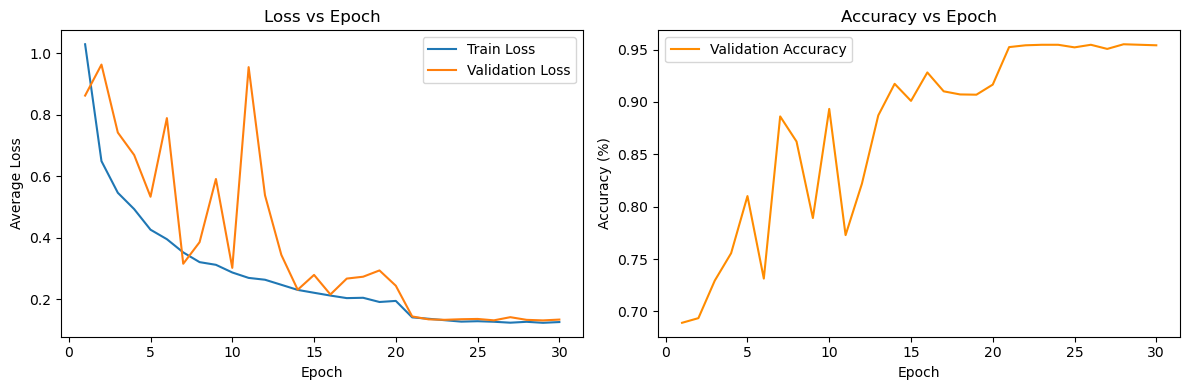

In [250]:

epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, label="Train Loss")
axes[0].plot(epochs, val_losses, label="Validation Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Loss")
axes[0].legend()

axes[1].plot(epochs, val_accuracies, label="Validation Accuracy", color="darkorange")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()